# Model Performance Impact of Feature Reliability

## Research Objective

The objective of this notebook is to investigate whether differences in feature reliability are associated with changes in machine learning model performance.

The analysis compares model performance under different feature conditions, including the complete feature set and feature subsets selected based on feature reliability characteristics.

The experiment aims to determine whether features exhibiting greater instability, distributional change, or inconsistent importance contribute to performance degradation.

This analysis provides the link between feature-level reliability and model-level performance, which is a central component of the proposed data-centric feature reliability framework.

## Research Question

Do differences in feature reliability lead to measurable changes in model performance?

### Supporting Questions

1. Does removing potentially less reliable features change model performance?
2. Do features with higher distributional variation contribute differently to model performance?
3. Does feature selection based on reliability characteristics improve or reduce predictive performance?
4. Are the observations consistent across different machine learning models?

## Experimental Design

The Loan Prediction dataset is used as the primary dataset for this experiment.

Five sequential sample windows are used to maintain consistency with the previous feature reliability analyses.

The following feature conditions will be compared:

### Condition 1 — All Features
The complete set of selected numerical features is used.

### Condition 2 — Reliability-Based Feature Set
Features identified as relatively stable and consistently important are retained.

### Condition 3 — Less Stable Feature Set
Features exhibiting relatively greater instability or importance variation are evaluated separately.

Model performance is then compared across these conditions.

The primary evaluation metrics will include accuracy, precision, recall, F1-score and ROC-AUC where applicable.

Performance differences will be examined to determine whether feature reliability characteristics are associated with measurable changes in model performance.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
loan_df = pd.read_csv("../datasets/loan_data_set.csv")

print("Dataset shape:", loan_df.shape)

loan_df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Define the modeling variables

In [4]:
loan_target = "Loan_Status"

loan_num_cols = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

loan_model_df = loan_df[
    loan_num_cols + [loan_target]
].copy()

# Encode target
loan_model_df[loan_target] = loan_model_df[loan_target].map({
    "Y": 1,
    "N": 0
})

print("Features:")
print(loan_num_cols)

print("\nTarget distribution:")
print(loan_model_df[loan_target].value_counts())

Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Target distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64


## Feature Groups Based on Earlier Reliability Analysis

The feature groups used in this experiment are derived from the stability and distributional analyses conducted in the previous notebooks.

### Full Feature Set

All five numerical features are included:

- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Loan_Amount_Term
- Credit_History

### Relatively Stable Feature Set

The following features showed comparatively stable distributional behavior across the sample windows:

- Credit_History
- Loan_Amount_Term

### Comparatively Less-Stable Feature Set

The following features exhibited comparatively greater variation in their distributional characteristics:

- ApplicantIncome
- CoapplicantIncome
- LoanAmount

These groups are experimental conditions and do not represent final reliable/unreliable classifications. The purpose is to examine whether differences in observed feature behavior are associated with differences in model performance.

### Create the Feature Groups

In [5]:
# Feature groups based on previous reliability analysis

all_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

stable_features = [
    "Credit_History",
    "Loan_Amount_Term"
]

less_stable_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount"
]

feature_groups = {
    "All Features": all_features,
    "Relatively Stable Features": stable_features,
    "Comparatively Less-Stable Features": less_stable_features
}

for group_name, features in feature_groups.items():
    print(f"\n{group_name}:")
    print(features)


All Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Relatively Stable Features:
['Credit_History', 'Loan_Amount_Term']

Comparatively Less-Stable Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']


### Visualize the Experimental Design

In [6]:
feature_group_summary = pd.DataFrame({
    "Feature": loan_num_cols,
    "Group": [
        "Less-Stable",
        "Less-Stable",
        "Less-Stable",
        "Stable",
        "Stable"
    ]
})

feature_group_summary

,Feature,Group
0,ApplicantIncome,Less-Stable
1,CoapplicantIncome,Less-Stable
2,LoanAmount,Less-Stable
3,Loan_Amount_Term,Stable
4,Credit_History,Stable


# Controlled Model Training

## Controlled Train-Test Split

A single stratified train-test split is created and reused across all feature conditions.

Using the same observations for every experiment ensures that differences in model performance are primarily associated with the selected feature set rather than differences in the train-test partition.

The target distribution is preserved using stratification.

In [7]:
# Prepare complete feature matrix and target

X = loan_model_df[all_features].copy()
y = loan_model_df[loan_target].copy()

# Fixed stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 491
Testing samples: 123

Training target distribution:
Loan_Status
1    0.686354
0    0.313646
Name: proportion, dtype: float64

Testing target distribution:
Loan_Status
1    0.691057
0    0.308943
Name: proportion, dtype: float64


## Define the Random Forest model

In [8]:
# Random Forest configuration

rf_params = {
    "n_estimators": 300,
    "random_state": 42,
    "class_weight": "balanced",
    "n_jobs": -1
}

print("Random Forest configuration:")
print(rf_params)

Random Forest configuration:
{'n_estimators': 300, 'random_state': 42, 'class_weight': 'balanced', 'n_jobs': -1}


## Build a reusable evaluation function

In [9]:
def evaluate_random_forest(X_train, X_test, y_train, y_test, features):
    """
    Train and evaluate a Random Forest model for a given feature set.
    Missing values are handled using median imputation fitted only on training data.
    """

    # Select features
    X_train_selected = X_train[features].copy()
    X_test_selected = X_test[features].copy()

    # Preprocessing + model pipeline
    model = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ])

    # Train
    model.fit(X_train_selected, y_train)

    # Predictions
    y_pred = model.predict(X_test_selected)
    y_prob = model.predict_proba(X_test_selected)[:, 1]

    # Metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    return model, results

## Evaluate the three feature conditions

In [10]:
model_results = []

for group_name, features in feature_groups.items():

    model, results = evaluate_random_forest(
        X_train,
        X_test,
        y_train,
        y_test,
        features
    )

    results["Feature_Set"] = group_name
    results["Number_of_Features"] = len(features)

    model_results.append(results)

rf_results_df = pd.DataFrame(model_results)

rf_results_df = rf_results_df[
    [
        "Feature_Set",
        "Number_of_Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

rf_results_df

,Feature_Set,Number_of_Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,All Features,5,0.788618,0.864198,0.823529,0.843373,0.836997
1,Relatively Stable Features,2,0.837398,0.828283,0.964706,0.891304,0.739164
2,Comparatively Less-Stable Features,3,0.577236,0.708861,0.658824,0.682927,0.550000


# Controlled Feature Ablation

## Feature Ablation Experiment

To further investigate the contribution of individual features to model performance, a feature ablation experiment is performed.

The complete five-feature model is used as the baseline. One feature is removed at a time while keeping the same train-test split, preprocessing procedure, Random Forest configuration, and evaluation metrics.

The change in model performance relative to the full-feature baseline is then measured.

This experiment helps quantify the performance contribution of individual features and provides additional evidence for evaluating the relationship between feature characteristics and model performance.

In [11]:
# Feature ablation experiment

ablation_results = []

# Baseline: all features
baseline_features = all_features.copy()

baseline_model, baseline_metrics = evaluate_random_forest(
    X_train,
    X_test,
    y_train,
    y_test,
    baseline_features
)

baseline_result = {
    "Condition": "All Features",
    "Removed_Feature": "None",
    **baseline_metrics
}

ablation_results.append(baseline_result)


# Remove one feature at a time
for feature_to_remove in all_features:

    remaining_features = [
        feature for feature in all_features
        if feature != feature_to_remove
    ]

    model, metrics = evaluate_random_forest(
        X_train,
        X_test,
        y_train,
        y_test,
        remaining_features
    )

    result = {
        "Condition": "Ablated",
        "Removed_Feature": feature_to_remove,
        **metrics
    }

    ablation_results.append(result)


ablation_df = pd.DataFrame(ablation_results)

ablation_df

,Condition,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,All Features,None,0.788618,0.864198,0.823529,0.843373,0.836997
1,Ablated,ApplicantIncome,0.739837,0.853333,0.752941,0.800000,0.791796
2,Ablated,CoapplicantIncome,0.772358,0.860759,0.800000,0.829268,0.800929
3,Ablated,LoanAmount,0.739837,0.853333,0.752941,0.800000,0.802786
4,Ablated,Loan_Amount_Term,0.764228,0.868421,0.776471,0.819876,0.834830
5,Ablated,Credit_History,0.650407,0.738636,0.764706,0.751445,0.593653


## Calculate performance change

In [12]:
# Baseline performance
baseline_accuracy = ablation_df.loc[
    ablation_df["Removed_Feature"] == "None",
    "Accuracy"
].iloc[0]

baseline_f1 = ablation_df.loc[
    ablation_df["Removed_Feature"] == "None",
    "F1"
].iloc[0]

baseline_auc = ablation_df.loc[
    ablation_df["Removed_Feature"] == "None",
    "ROC_AUC"
].iloc[0]


# Performance changes
ablation_df["Accuracy_Change"] = (
    ablation_df["Accuracy"] - baseline_accuracy
)

ablation_df["F1_Change"] = (
    ablation_df["F1"] - baseline_f1
)

ablation_df["ROC_AUC_Change"] = (
    ablation_df["ROC_AUC"] - baseline_auc
)

ablation_df

,Condition,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC,Accuracy_Change,F1_Change,ROC_AUC_Change
0,All Features,None,0.788618,0.864198,0.823529,0.843373,0.836997,0.000000,0.000000,0.000000
1,Ablated,ApplicantIncome,0.739837,0.853333,0.752941,0.800000,0.791796,-0.048780,-0.043373,-0.045201
2,Ablated,CoapplicantIncome,0.772358,0.860759,0.800000,0.829268,0.800929,-0.016260,-0.014105,-0.036068
3,Ablated,LoanAmount,0.739837,0.853333,0.752941,0.800000,0.802786,-0.048780,-0.043373,-0.034211
4,Ablated,Loan_Amount_Term,0.764228,0.868421,0.776471,0.819876,0.834830,-0.024390,-0.023498,-0.002167
5,Ablated,Credit_History,0.650407,0.738636,0.764706,0.751445,0.593653,-0.138211,-0.091928,-0.243344


# Visualize the performance impact

## Feature Ablation Performance Impact

The following visualization shows the change in model performance after removing each feature relative to the complete-feature baseline. Negative values indicate performance degradation after feature removal.

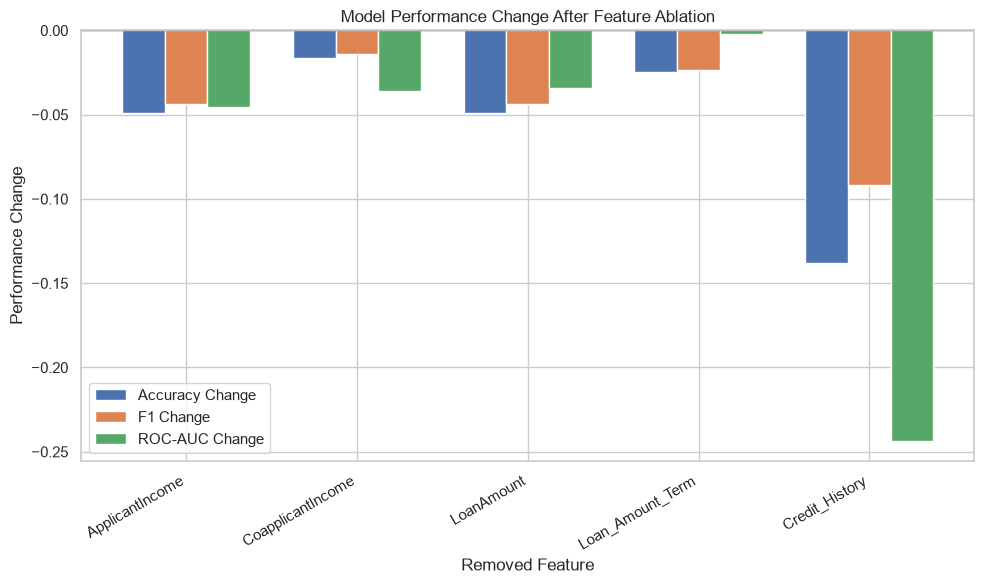

In [13]:
# Prepare ablation results excluding the baseline

ablation_plot_df = ablation_df[
    ablation_df["Removed_Feature"] != "None"
].copy()

plt.figure(figsize=(10, 6))

x = np.arange(len(ablation_plot_df))
width = 0.25

plt.bar(
    x - width,
    ablation_plot_df["Accuracy_Change"],
    width,
    label="Accuracy Change"
)

plt.bar(
    x,
    ablation_plot_df["F1_Change"],
    width,
    label="F1 Change"
)

plt.bar(
    x + width,
    ablation_plot_df["ROC_AUC_Change"],
    width,
    label="ROC-AUC Change"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(
    x,
    ablation_plot_df["Removed_Feature"],
    rotation=30,
    ha="right"
)

plt.ylabel("Performance Change")
plt.xlabel("Removed Feature")
plt.title("Model Performance Change After Feature Ablation")
plt.legend()
plt.tight_layout()
plt.show()

## Create a concise impact ranking

In [14]:
feature_impact_summary = ablation_df[
    ablation_df["Removed_Feature"] != "None"
][[
    "Removed_Feature",
    "Accuracy_Change",
    "F1_Change",
    "ROC_AUC_Change"
]].copy()

# Calculate average magnitude of performance degradation
feature_impact_summary["Mean_Performance_Impact"] = (
    feature_impact_summary[
        ["Accuracy_Change", "F1_Change", "ROC_AUC_Change"]
    ].abs().mean(axis=1)
)

feature_impact_summary = feature_impact_summary.sort_values(
    "Mean_Performance_Impact",
    ascending=False
)

feature_impact_summary

,Removed_Feature,Accuracy_Change,F1_Change,ROC_AUC_Change,Mean_Performance_Impact
5,Credit_History,-0.138211,-0.091928,-0.243344,0.157828
1,ApplicantIncome,-0.048780,-0.043373,-0.045201,0.045785
3,LoanAmount,-0.048780,-0.043373,-0.034211,0.042122
2,CoapplicantIncome,-0.016260,-0.014105,-0.036068,0.022144
4,Loan_Amount_Term,-0.024390,-0.023498,-0.002167,0.016685


# Cross-Model Performance Impact

## Cross-Model Validation of Feature Performance Impact

To determine whether the observed feature-performance relationship is specific to Random Forest or is more general across model families, the feature ablation experiment is repeated using Logistic Regression and Gradient Boosting.

The same train-test split, feature sets, preprocessing strategy, and evaluation metrics are maintained across models.

This allows the performance impact of individual features to be compared across different learning algorithms.

In [16]:
# Create a general evaluation function

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    features
):
    """
    Train and evaluate a model for a selected feature set.
    Median imputation is fitted only on the training data.
    """

    X_train_selected = X_train[features].copy()
    X_test_selected = X_test[features].copy()

    pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(X_train_selected, y_train)

    y_pred = pipeline.predict(X_test_selected)
    y_prob = pipeline.predict_proba(X_test_selected)[:, 1]

    results = {
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        )
    }

    return pipeline, results

### Define the two additional models

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "Gradient Boosting": gradient_boosting_model
}

print("Models prepared:")
for name in models:
    print("-", name)

Models prepared:
- Logistic Regression
- Gradient Boosting


In [18]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    features,
    scale=False
):
    """
    Train and evaluate a model for a selected feature set.
    """

    X_train_selected = X_train[features].copy()
    X_test_selected = X_test[features].copy()

    steps = [
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]

    if scale:
        steps.append(
            ("scaler", StandardScaler())
        )

    steps.append(
        ("model", model)
    )

    pipeline = Pipeline(steps)

    pipeline.fit(
        X_train_selected,
        y_train
    )

    y_pred = pipeline.predict(
        X_test_selected
    )

    y_prob = pipeline.predict_proba(
        X_test_selected
    )[:, 1]

    results = {
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        )
    }

    return pipeline, results

### Run Logistic Regression ablation

In [19]:
logistic_ablation_results = []

# Baseline
_, baseline_metrics = evaluate_model(
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test,
    all_features,
    scale=True
)

logistic_ablation_results.append({
    "Model": "Logistic Regression",
    "Removed_Feature": "None",
    **baseline_metrics
})

# One feature removed at a time
for feature_to_remove in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != feature_to_remove
    ]

    _, metrics = evaluate_model(
        logistic_model,
        X_train,
        X_test,
        y_train,
        y_test,
        remaining_features,
        scale=True
    )

    logistic_ablation_results.append({
        "Model": "Logistic Regression",
        "Removed_Feature": feature_to_remove,
        **metrics
    })

logistic_ablation_df = pd.DataFrame(
    logistic_ablation_results
)

logistic_ablation_df

,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,None,0.861789,0.840000,0.988235,0.908108,0.777090
1,Logistic Regression,ApplicantIncome,0.861789,0.840000,0.988235,0.908108,0.772136
2,Logistic Regression,CoapplicantIncome,0.853659,0.831683,0.988235,0.903226,0.809288
3,Logistic Regression,LoanAmount,0.861789,0.840000,0.988235,0.908108,0.745666
4,Logistic Regression,Loan_Amount_Term,0.861789,0.840000,0.988235,0.908108,0.781734
5,Logistic Regression,Credit_History,0.414634,0.584416,0.529412,0.555556,0.328173


### Gradient Boosting ablation

In [20]:
gb_ablation_results = []

# Baseline
_, baseline_metrics = evaluate_model(
    gradient_boosting_model,
    X_train,
    X_test,
    y_train,
    y_test,
    all_features,
    scale=False
)

gb_ablation_results.append({
    "Model": "Gradient Boosting",
    "Removed_Feature": "None",
    **baseline_metrics
})

# One feature removed at a time
for feature_to_remove in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != feature_to_remove
    ]

    _, metrics = evaluate_model(
        gradient_boosting_model,
        X_train,
        X_test,
        y_train,
        y_test,
        remaining_features,
        scale=False
    )

    gb_ablation_results.append({
        "Model": "Gradient Boosting",
        "Removed_Feature": feature_to_remove,
        **metrics
    })

gb_ablation_df = pd.DataFrame(
    gb_ablation_results
)

gb_ablation_df

,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,None,0.804878,0.808081,0.941176,0.869565,0.716254
1,Gradient Boosting,ApplicantIncome,0.829268,0.833333,0.941176,0.883978,0.756966
2,Gradient Boosting,CoapplicantIncome,0.821138,0.824742,0.941176,0.879121,0.752322
3,Gradient Boosting,LoanAmount,0.837398,0.835052,0.952941,0.890110,0.778173
4,Gradient Boosting,Loan_Amount_Term,0.813008,0.816327,0.941176,0.874317,0.734211
5,Gradient Boosting,Credit_History,0.682927,0.716981,0.894118,0.795812,0.532663


## Cross-Model Comparison of Feature Performance Impact

The feature ablation experiment was repeated using Random Forest,
Logistic Regression, and Gradient Boosting to determine whether the
observed relationship between feature reliability and model performance
is consistent across different learning algorithms.

The same train-test split, preprocessing strategy, feature set, and
evaluation metrics were maintained across the three models.

The results show that Credit_History has the largest performance impact
across all three models. Removing Credit_History caused substantial
degradation in Accuracy, F1-score, and ROC-AUC for Random Forest,
Logistic Regression, and Gradient Boosting.

In contrast, the effects of ApplicantIncome, CoapplicantIncome,
LoanAmount, and Loan_Amount_Term were more model-dependent. In
Gradient Boosting, removing several of these features even improved
performance, indicating that feature contribution is not determined
solely by distributional stability.

These findings demonstrate that feature reliability and predictive
importance are related but distinct properties. A statistically stable
feature may be highly important for prediction, while a comparatively
less-stable feature does not necessarily cause performance degradation.

Therefore, feature reliability should be evaluated using multiple
dimensions rather than a single stability or importance measure.

## the final comparison DataFrame

In [22]:
# Random Forest ablation results

rf_ablation_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Removed_Feature": "None",
        "Accuracy": 0.788618,
        "Precision": 0.864198,
        "Recall": 0.823529,
        "F1": 0.843373,
        "ROC_AUC": 0.836997
    },
    {
        "Model": "Random Forest",
        "Removed_Feature": "ApplicantIncome",
        "Accuracy": 0.739837,
        "Precision": 0.853333,
        "Recall": 0.752941,
        "F1": 0.800000,
        "ROC_AUC": 0.791796
    },
    {
        "Model": "Random Forest",
        "Removed_Feature": "CoapplicantIncome",
        "Accuracy": 0.772358,
        "Precision": 0.860759,
        "Recall": 0.800000,
        "F1": 0.829268,
        "ROC_AUC": 0.800929
    },
    {
        "Model": "Random Forest",
        "Removed_Feature": "LoanAmount",
        "Accuracy": 0.739837,
        "Precision": 0.853333,
        "Recall": 0.752941,
        "F1": 0.800000,
        "ROC_AUC": 0.802786
    },
    {
        "Model": "Random Forest",
        "Removed_Feature": "Loan_Amount_Term",
        "Accuracy": 0.764228,
        "Precision": 0.868421,
        "Recall": 0.776471,
        "F1": 0.819876,
        "ROC_AUC": 0.834830
    },
    {
        "Model": "Random Forest",
        "Removed_Feature": "Credit_History",
        "Accuracy": 0.650407,
        "Precision": 0.738636,
        "Recall": 0.764706,
        "F1": 0.751445,
        "ROC_AUC": 0.593653
    }
])

rf_ablation_df

,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,None,0.788618,0.864198,0.823529,0.843373,0.836997
1,Random Forest,ApplicantIncome,0.739837,0.853333,0.752941,0.800000,0.791796
2,Random Forest,CoapplicantIncome,0.772358,0.860759,0.800000,0.829268,0.800929
3,Random Forest,LoanAmount,0.739837,0.853333,0.752941,0.800000,0.802786
4,Random Forest,Loan_Amount_Term,0.764228,0.868421,0.776471,0.819876,0.834830
5,Random Forest,Credit_History,0.650407,0.738636,0.764706,0.751445,0.593653


In [23]:
print("Logistic Regression:")
display(logistic_ablation_df)

print("\nGradient Boosting:")
display(gb_ablation_df)

Logistic Regression:


,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,None,0.861789,0.840000,0.988235,0.908108,0.777090
1,Logistic Regression,ApplicantIncome,0.861789,0.840000,0.988235,0.908108,0.772136
2,Logistic Regression,CoapplicantIncome,0.853659,0.831683,0.988235,0.903226,0.809288
3,Logistic Regression,LoanAmount,0.861789,0.840000,0.988235,0.908108,0.745666
4,Logistic Regression,Loan_Amount_Term,0.861789,0.840000,0.988235,0.908108,0.781734
5,Logistic Regression,Credit_History,0.414634,0.584416,0.529412,0.555556,0.328173



Gradient Boosting:


,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Gradient Boosting,None,0.804878,0.808081,0.941176,0.869565,0.716254
1,Gradient Boosting,ApplicantIncome,0.829268,0.833333,0.941176,0.883978,0.756966
2,Gradient Boosting,CoapplicantIncome,0.821138,0.824742,0.941176,0.879121,0.752322
3,Gradient Boosting,LoanAmount,0.837398,0.835052,0.952941,0.890110,0.778173
4,Gradient Boosting,Loan_Amount_Term,0.813008,0.816327,0.941176,0.874317,0.734211
5,Gradient Boosting,Credit_History,0.682927,0.716981,0.894118,0.795812,0.532663


In [24]:
# Combine ablation results from all three models

cross_model_ablation_df = pd.concat(
    [
        rf_ablation_df,
        logistic_ablation_df,
        gb_ablation_df
    ],
    ignore_index=True
)

cross_model_ablation_df

,Model,Removed_Feature,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,None,0.788618,0.864198,0.823529,0.843373,0.836997
1,Random Forest,ApplicantIncome,0.739837,0.853333,0.752941,0.800000,0.791796
2,Random Forest,CoapplicantIncome,0.772358,0.860759,0.800000,0.829268,0.800929
3,Random Forest,LoanAmount,0.739837,0.853333,0.752941,0.800000,0.802786
4,Random Forest,Loan_Amount_Term,0.764228,0.868421,0.776471,0.819876,0.834830
5,Random Forest,Credit_History,0.650407,0.738636,0.764706,0.751445,0.593653
6,Logistic Regression,None,0.861789,0.840000,0.988235,0.908108,0.777090
7,Logistic Regression,ApplicantIncome,0.861789,0.840000,0.988235,0.908108,0.772136
8,Logistic Regression,CoapplicantIncome,0.853659,0.831683,0.988235,0.903226,0.809288
9,Logistic Regression,LoanAmount,0.861789,0.840000,0.988235,0.908108,0.745666


In [26]:
# Extract baseline ROC-AUC for each model

baseline_auc = (
    cross_model_ablation_df[
        cross_model_ablation_df["Removed_Feature"] == "None"
    ]
    .set_index("Model")["ROC_AUC"]
)

roc_auc_impact = cross_model_ablation_df[
    cross_model_ablation_df["Removed_Feature"] != "None"
].copy()

roc_auc_impact["ROC_AUC_Change"] = roc_auc_impact.apply(
    lambda row: row["ROC_AUC"] - baseline_auc[row["Model"]],
    axis=1
)

roc_auc_impact[
    ["Model", "Removed_Feature", "ROC_AUC", "ROC_AUC_Change"]
]

,Model,Removed_Feature,ROC_AUC,ROC_AUC_Change
1,Random Forest,ApplicantIncome,0.791796,-0.045201
2,Random Forest,CoapplicantIncome,0.800929,-0.036068
3,Random Forest,LoanAmount,0.802786,-0.034211
4,Random Forest,Loan_Amount_Term,0.834830,-0.002167
5,Random Forest,Credit_History,0.593653,-0.243344
7,Logistic Regression,ApplicantIncome,0.772136,-0.004954
8,Logistic Regression,CoapplicantIncome,0.809288,0.032198
9,Logistic Regression,LoanAmount,0.745666,-0.031424
10,Logistic Regression,Loan_Amount_Term,0.781734,0.004644
11,Logistic Regression,Credit_History,0.328173,-0.448916


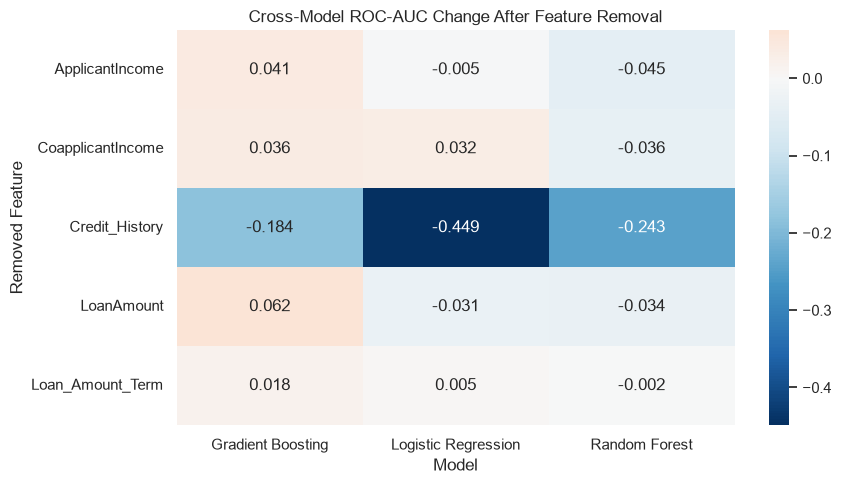

In [28]:
# Cross-model ROC-AUC impact heatmap

roc_auc_heatmap = roc_auc_impact.pivot(
    index="Removed_Feature",
    columns="Model",
    values="ROC_AUC_Change"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    roc_auc_heatmap,
    annot=True,
    fmt=".3f",
    center=0,
    cmap="RdBu_r"
)

plt.title("Cross-Model ROC-AUC Change After Feature Removal")
plt.xlabel("Model")
plt.ylabel("Removed Feature")
plt.tight_layout()
plt.show()

### Interpretation of Cross-Model ROC-AUC Analysis

The heatmap shows the change in ROC-AUC after removing each feature from
Random Forest, Logistic Regression, and Gradient Boosting models.

The most consistent observation is the effect of `Credit_History`.
Removing this feature resulted in a substantial decrease in ROC-AUC
across all three models:

- Random Forest: decrease of 0.243
- Logistic Regression: decrease of 0.449
- Gradient Boosting: decrease of 0.184

This indicates that `Credit_History` makes a strong and consistent
contribution to predictive performance across different model families.

In contrast, the effects of `ApplicantIncome`, `CoapplicantIncome`,
`LoanAmount`, and `Loan_Amount_Term` are relatively smaller and
model-dependent. For Gradient Boosting, removing these features
resulted in an improvement in ROC-AUC, whereas Random Forest generally
showed a small performance decrease.

Therefore, feature contribution to model performance is not determined
solely by feature stability or distributional behavior. The relationship
between feature characteristics and predictive performance can vary
across learning algorithms.

The cross-model analysis strengthens the evidence that `Credit_History`
is a particularly important feature for the Loan Prediction task.
However, this result should be interpreted as evidence of predictive
importance and performance contribution rather than as a final
classification of feature reliability.

## Conclusion

This notebook investigated whether differences in feature behavior are
associated with differences in machine learning model performance.

The analysis evaluated feature groups based on their observed
distributional stability and then examined their impact on model
performance using feature ablation. Random Forest, Logistic Regression,
and Gradient Boosting were evaluated using the same train-test split
and consistent performance metrics.

The results show that the relatively stable feature subset containing
`Credit_History` and `Loan_Amount_Term` achieved stronger performance
than the comparatively less-stable feature subset for the Random Forest
experiment. However, the results also demonstrate that feature
stability alone does not determine predictive usefulness.

The individual feature ablation analysis provided a stronger insight.
`Credit_History` produced the largest performance degradation when
removed from the Random Forest model. This observation was further
validated across Logistic Regression and Gradient Boosting, where
removing `Credit_History` also caused substantial reductions in
ROC-AUC.

In contrast, the performance effects of `ApplicantIncome`,
`CoapplicantIncome`, `LoanAmount`, and `Loan_Amount_Term` were smaller
and varied across model families. Some features even produced improved
performance when removed from Gradient Boosting, indicating that
feature contribution is model-dependent.

Overall, the findings demonstrate that feature stability, distributional
behavior, feature importance, and predictive contribution represent
different dimensions of feature behavior. Therefore, feature reliability
should not be determined using a single metric.

These findings provide the basis for the next stage of the research:
integrating stability, drift, importance consistency, and performance
impact into a unified feature reliability framework.